# <span style="color:black; font-weight:bold;">RNA-ATAC simulation data alignment Tutorial</span>
+ <span style="color:black; font-weight:bold;">Creator</span>: Bingjie Dai (17516970902@163.com)
+ <span style="color:black; font-weight:bold;">Date of Creation</span>: 8.23.2026
+ <span style="color:black; font-weight:bold;">Date of Last Modification</span>: 8.23.2026
+ <span style="color:black; font-weight:bold;">Download</span>: Epigenomic simulation data data used in the tutorial are available at [Simulation data](https://drive.google.com/drive/folders/1xCSnAt2H8YuV1vHC3ywz7t6idI3JJlro?usp=sharing).
In this tutorial we apply MAPS to align four RNA-ATAC simulation dataset, inclduing Layers, Island, Enhanced, enhanced. 

<span style="color:black; font-weight:bold;">The dataset have:</span>   
+ <span style="color:black; font-weight:bold;">Layers(ATAC)</span>: 2400 spots and 390 features  
+ <span style="color:black; font-weight:bold;">Layers(RNA)</span>: 2400 spots and 130 features  
+ <span style="color:black; font-weight:bold;">Island(ATAC)</span>: 2500 spots and 390 features    
+ <span style="color:black; font-weight:bold;">Island(RNA)</span>: 2500 spots and 130 features   
+ <span style="color:black; font-weight:bold;">Enhanced(ATAC)</span>: 2000 spots and 390 features    
+ <span style="color:black; font-weight:bold;">Enhanced(RNA)</span>: 2000 spots and 130 features   
+ <span style="color:black; font-weight:bold;">enhanced(ATAC)</span>: 2100 spots and 390 features      
+ <span style="color:black; font-weight:bold;">enhanced(RNA)</span>: 2100 spots and 130 features 

In [1]:
from MAPS.align import Rigid_alignment,Multi_slices_rigid_alignment
from MAPS.utils import set_seed,rotate_and_translate_spatial,create_new_color_dict,plot_2d_alignment_to_3d_flow
from MAPS.Evaluation import evaluation
import scanpy as sc
import pandas as pd
import torch
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [3]:
set_seed(7)

## <span style="color:black; font-weight:bold;">Loading Layers data</span>

In [4]:
source_adata=sc.read_h5ad('/home/dbj/LPcross/Data/data/alignment_sim/ATAC_sim/layers/adata_atac_sim5.h5ad')
source_adata.obs['batch']='ATAC'

target_adata=sc.read_h5ad('/home/dbj/LPcross/Data/data/alignment_sim/RNA_sim/layers/adata_rna_trans_sim5.h5ad')
target_adata.obs['batch']='ST'

### Rotate and translate the source data 

In [5]:
rotate_and_translate_spatial(source_adata,angle_deg=90,dx=20,dy=20)

## <span style="color:black; font-weight:bold;">Spatial mapping of the Layers data before alignment</span>

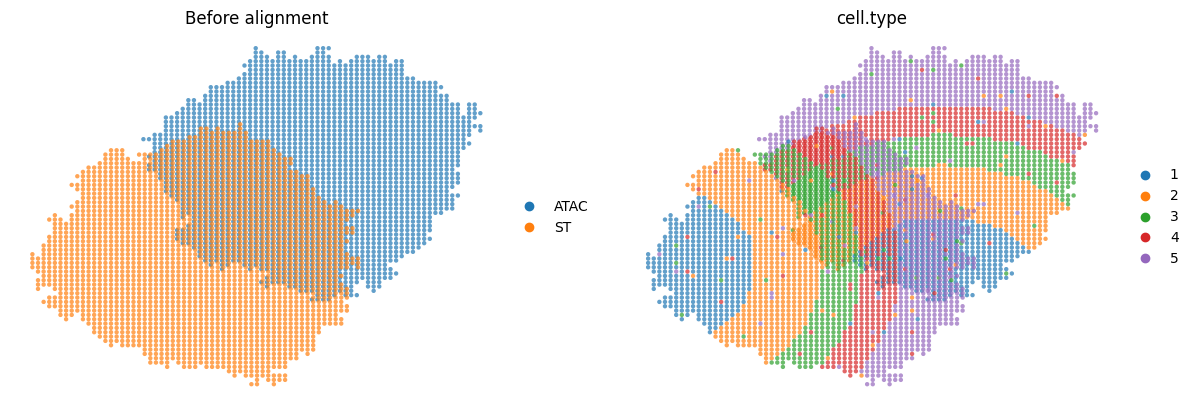

In [6]:
adata=sc.concat([source_adata,target_adata],join='inner')
sc.pl.embedding(adata=adata, basis='spatial',color=['batch','cell.type'],title='Before alignment',size=40,alpha=0.7,frameon=False)

## <span style="color:black; font-weight:bold;">Align the slices using MAPS</span> 
### <span style="color:black; font-weight:bold;">Training parameters</span> 
+ epochs: Training ephchs  
+ device: Training device  
+ sample_size: The number of samples used for alignment  
+ enable_scale: Whether to learn the scaling factor?  

### <span style="color:black; font-weight:bold;">Output</span>   
+ aligned_spatial: The coordinates of the source slices after alignment  
+ theta_deg: Angle of rotation  
+ translation: Translation matrix  
+ scale: Scaling factor  

In [7]:
%%time
source = source_adata.obsm['spatial'].astype(np.float32) 
target = target_adata.obsm['spatial'].astype(np.float32)  

aligned_spatial, theta_deg, translation,scale= Rigid_alignment(source, target, epochs=1000, sample_size=10000,enable_scale=False,device=device)
source_adata.obsm['spatial'] = aligned_spatial

Scanning angles to find best starting angle...


Global Align: 100%|███████████████████████████████████| 1000/1000 [00:02<00:00, 357.07it/s, Loss=0.06, Scale=1.000, Rot=-89.71°, Trans=(-20.0, -20.0)]

Peak GPU memory usage: 0.124 GB
Scale factor: 1.000, Rotation angle: -90.16°, Translation (x, y): (-20.00, -20.00)
CPU times: user 3.5 s, sys: 709 ms, total: 4.2 s
Wall time: 4.41 s


## <span style="color:black; font-weight:bold;">Spatial mapping of the Layers after alignment</span>

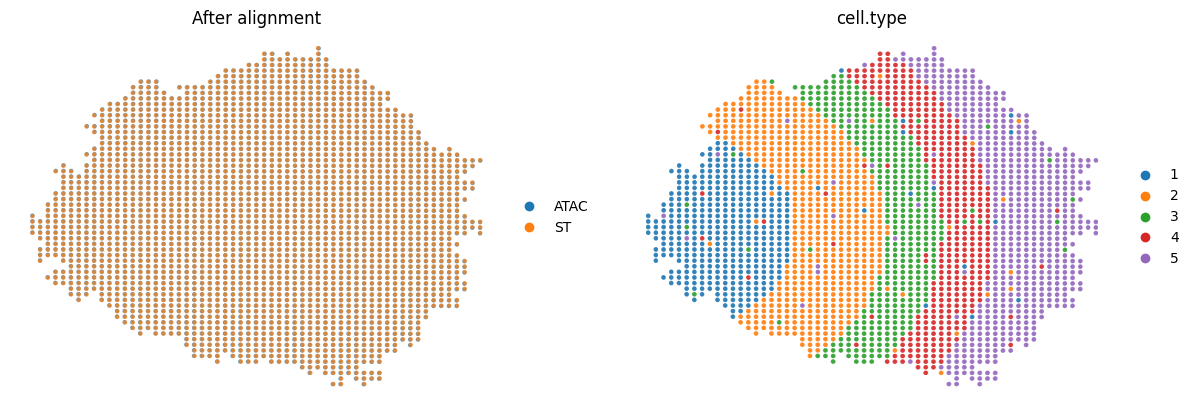

In [8]:
adata=sc.concat([source_adata,target_adata],join='inner')
sc.pl.embedding(adata=adata, basis='spatial',color=['batch','cell.type'],title='After alignment',size=40,alpha=0.7,frameon=False)

## <span style="color:black; font-weight:bold;">Cell type matching index(CI)</span> 

In [10]:
CI=evaluation(source_adata.obsm['spatial'],target_adata.obsm['spatial'],source_adata.obs['cell.type'],target_adata.obs['cell.type'])
CI

1.0

## <span style="color:black; font-weight:bold;">Visualization of the 3D alignment flow</span>

Connected sampling (total 50):
   - Correct pairing (Black): 50
   - Incorrect pairing (red): 0


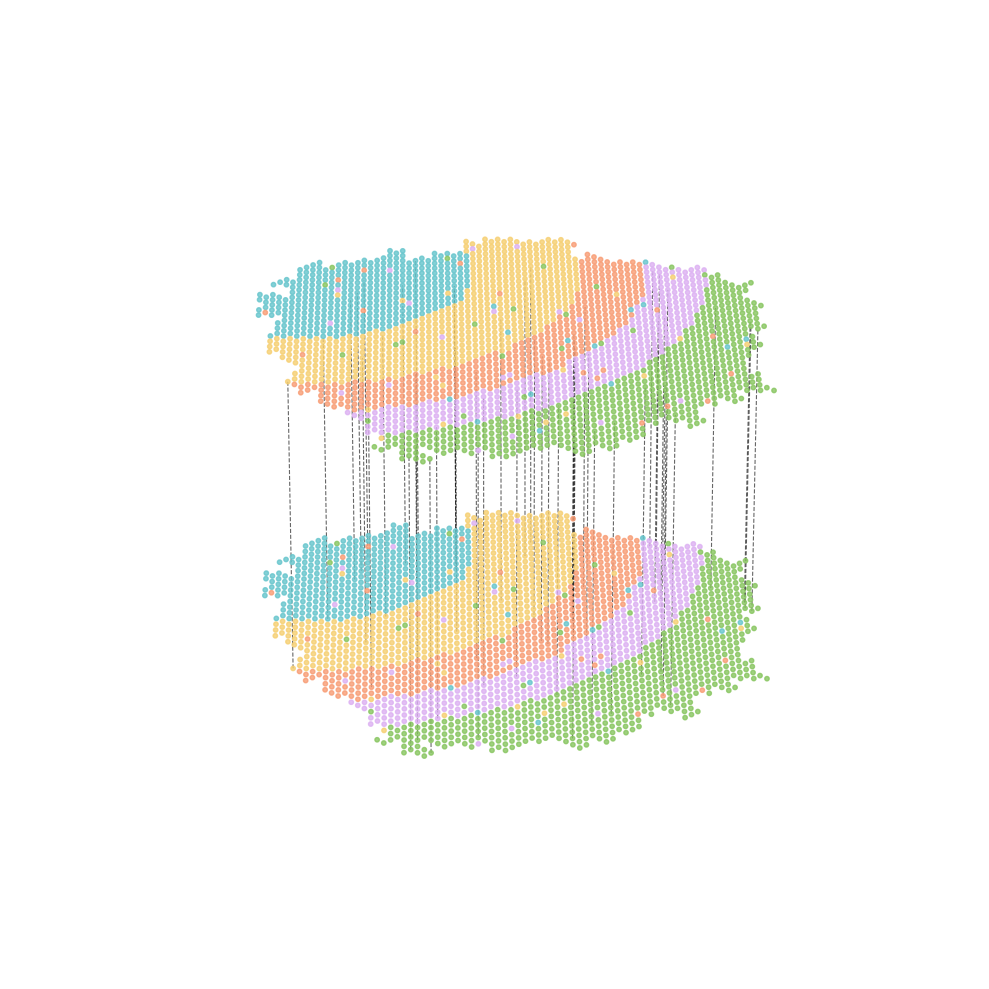

In [11]:
color_dict=create_new_color_dict(adata,cat_key='cell.type')
plot_2d_alignment_to_3d_flow(
    source_adata=source_adata,
    target_adata=target_adata,
    label_key='cell.type',        
    palette=color_dict,        
    n_lines=50,               
    height_scale=0.4,
    alpha_points=0.8,
    size=10,                  
    #save_path='/home/dbj/LPcross/Data/result/simATAC_align/alignment_flow_3d.png'
)

## <span style="color:black; font-weight:bold;">The correct alignment ratios for different regions</span> 

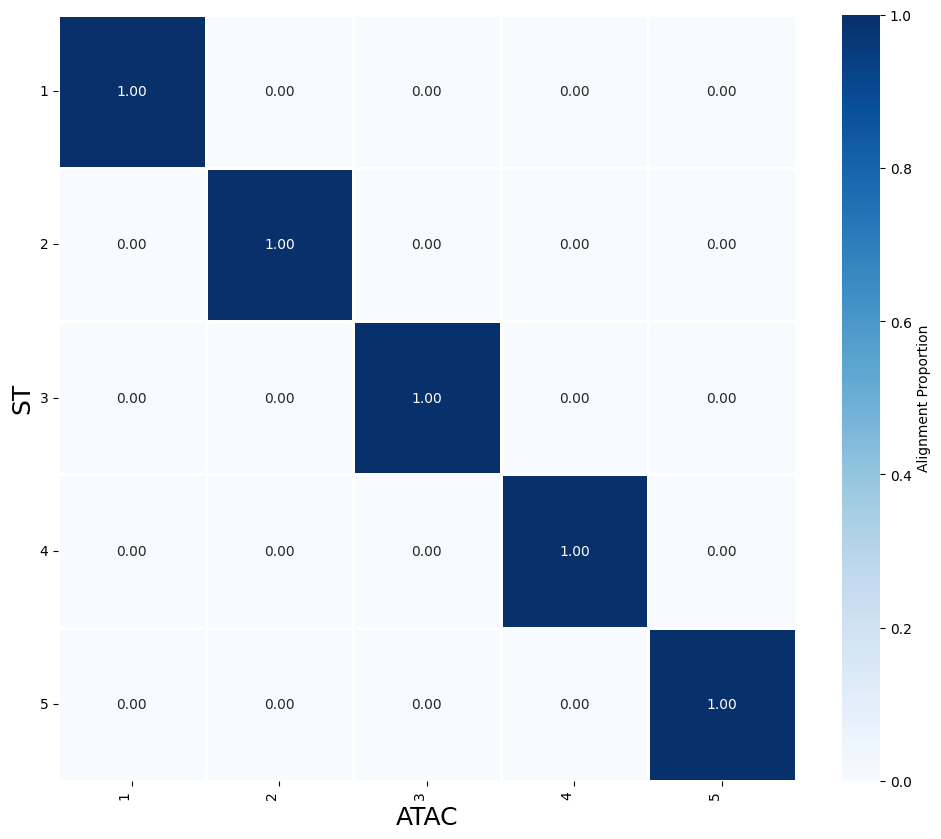

In [13]:
from scipy.spatial import cKDTree
import seaborn as sns
import matplotlib.pyplot as plt
source_label_key = 'cell.type' 
target_label_key = 'cell.type'
source_coords = source_adata.obsm['spatial']  
target_coords = target_adata.obsm['spatial']

tree = cKDTree(target_coords)
distances, indices = tree.query(source_coords, k=1)

source_labels = source_adata.obs[source_label_key].values
matched_target_labels = target_adata.obs[target_label_key].iloc[indices.flatten()].values

df_crosstab = pd.crosstab(
    index=pd.Series(matched_target_labels, name='Target Labels (Y)'),
    columns=pd.Series(source_labels, name='Source Labels (X)'),
    normalize='columns' 
)

plt.figure(figsize=(10, 8.5))
sns.heatmap(df_crosstab, annot=True,cmap='Blues',fmt='.2f',linewidths=1, cbar_kws={'label': 'Alignment Proportion'})
plt.grid(False) 
plt.title('', fontsize=14, pad=15)
plt.xlabel('ATAC', fontsize=18)
plt.ylabel('ST', fontsize=18)
plt.xticks(rotation=90, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## <span style="color:black; font-weight:bold;">Loading Island data</span>

In [7]:
source_adata=sc.read_h5ad('/home/dbj/LPcross/Data/data/alignment_sim/ATAC_sim/island/adata_atac_sim5.h5ad')
source_adata.obs['batch']='ATAC'


target_adata=sc.read_h5ad('/home/dbj/LPcross/Data/data/alignment_sim/RNA_sim/island/adata_rna_trans_sim5.h5ad')
target_adata.obs['batch']='ST'

In [15]:
rotate_and_translate_spatial(source_adata,angle_deg=90,dx=20,dy=20)

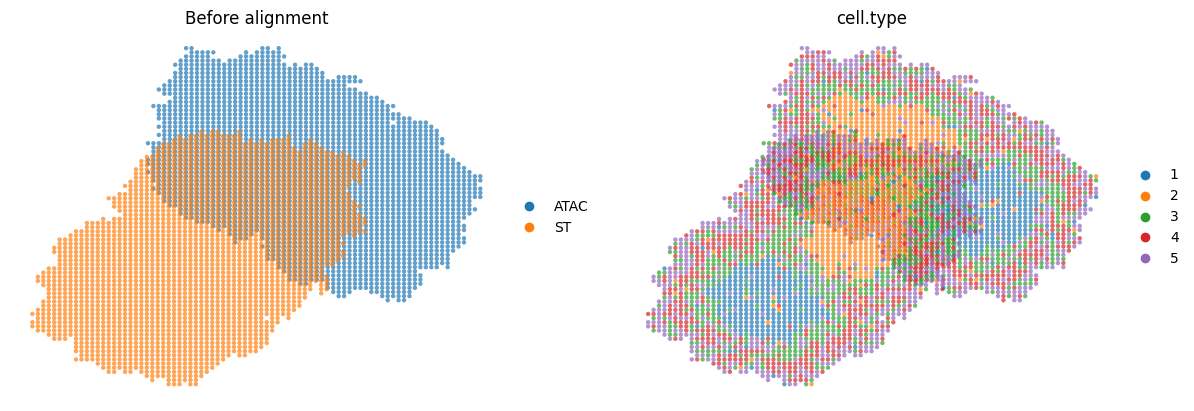

In [16]:
adata=sc.concat([source_adata,target_adata],join='inner')
sc.pl.embedding(adata=adata, basis='spatial',color=['batch','cell.type'],title='Before alignment',size=40,alpha=0.7,frameon=False)

In [17]:
%%time
source = source_adata.obsm['spatial'].astype(np.float32) 
target = target_adata.obsm['spatial'].astype(np.float32)  

aligned_spatial, theta_deg, translation,scale= Rigid_alignment(source, target, epochs=1000, sample_size=10000,enable_scale=False,device=device)
source_adata.obsm['spatial'] = aligned_spatial

Scanning angles to find best starting angle...


Global Align: 100%|███████████████████████████████████| 1000/1000 [00:02<00:00, 449.54it/s, Loss=0.04, Scale=1.000, Rot=-89.93°, Trans=(-20.0, -20.0)]

Peak GPU memory usage: 0.134 GB
Scale factor: 1.000, Rotation angle: -90.01°, Translation (x, y): (-20.00, -20.03)
CPU times: user 2.29 s, sys: 24.3 ms, total: 2.31 s
Wall time: 2.29 s


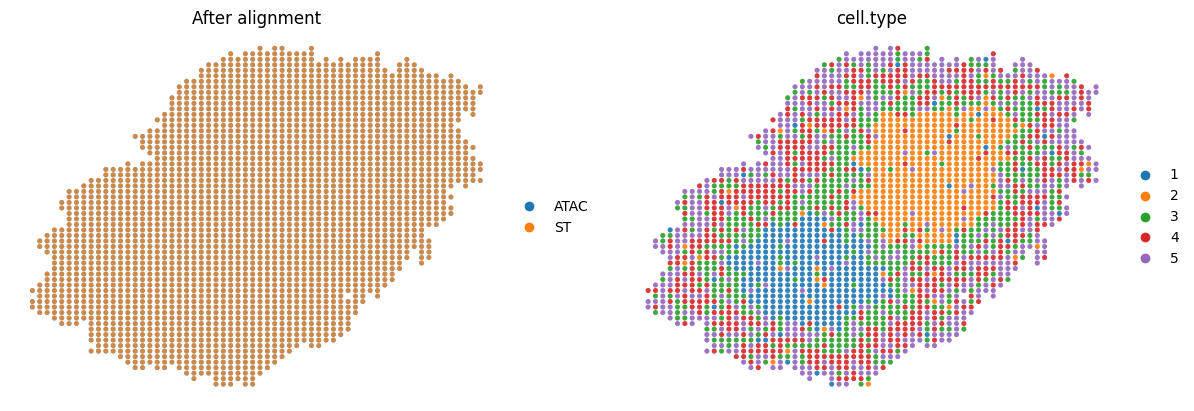

In [19]:
adata=sc.concat([source_adata,target_adata],join='inner')
sc.pl.embedding(adata=adata, basis='spatial',color=['batch','cell.type'],title='After alignment',size=50,alpha=0.7,frameon=False)

In [20]:
CI=evaluation(source_adata.obsm['spatial'],target_adata.obsm['spatial'],source_adata.obs['cell.type'],target_adata.obs['cell.type'])
CI

1.0

Connected sampling (total 50):
   - Correct pairing (Black): 50
   - Incorrect pairing (red): 0


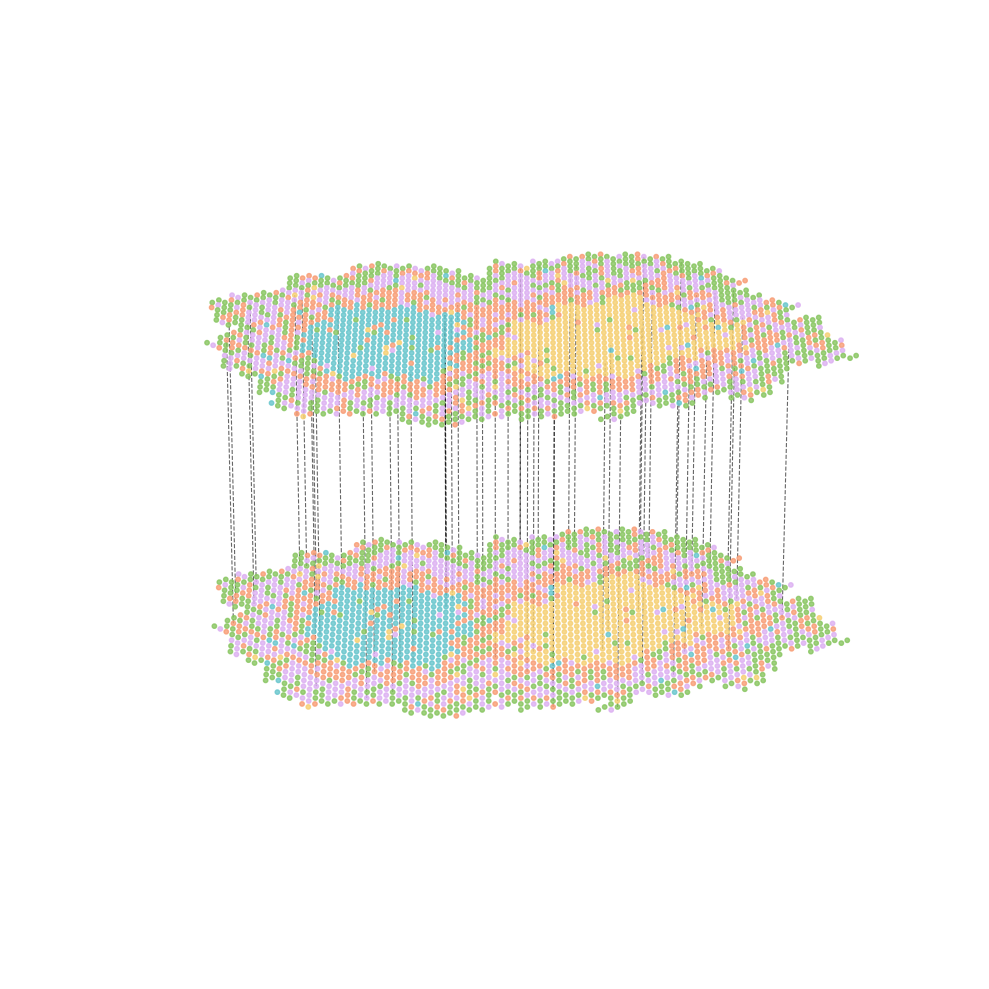

In [21]:
color_dict=create_new_color_dict(adata,cat_key='cell.type')
plot_2d_alignment_to_3d_flow(
    source_adata=source_adata,
    target_adata=target_adata,
    label_key='cell.type',        
    palette=color_dict,        
    n_lines=50,               
    height_scale=0.4,
    alpha_points=0.8,
    size=10,                  
    #save_path='/home/dbj/LPcross/Data/result/simATAC_align/alignment_flow_3d.png'
)

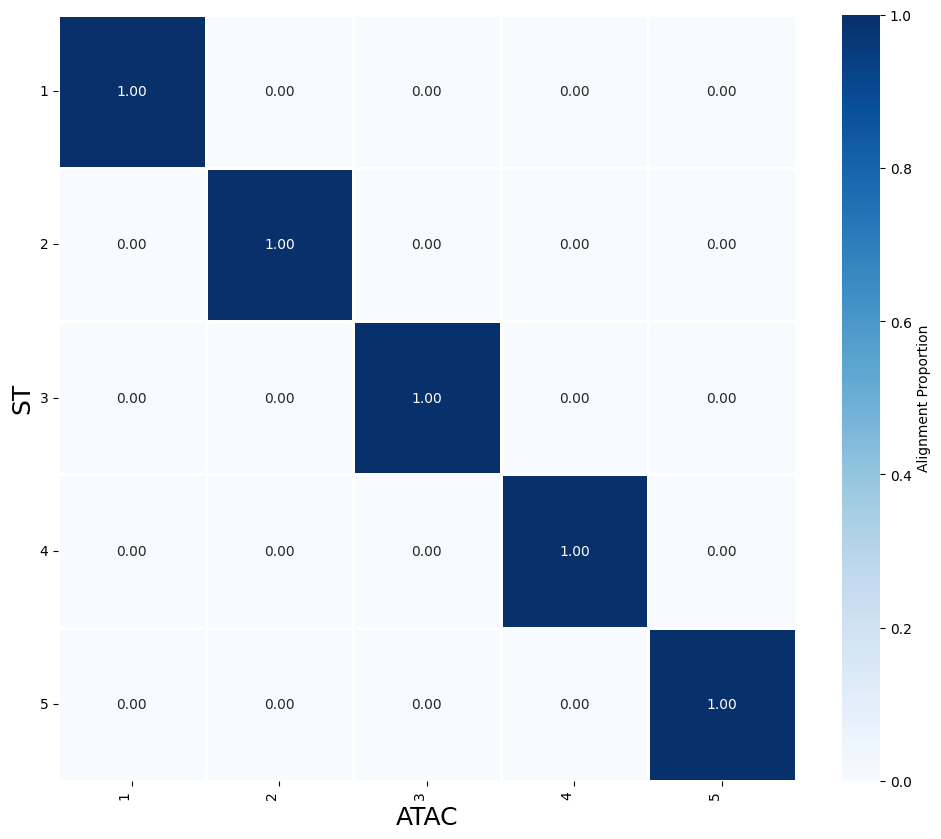

In [22]:
from scipy.spatial import cKDTree
import seaborn as sns
import matplotlib.pyplot as plt
source_label_key = 'cell.type' 
target_label_key = 'cell.type'
source_coords = source_adata.obsm['spatial']  
target_coords = target_adata.obsm['spatial']

tree = cKDTree(target_coords)
distances, indices = tree.query(source_coords, k=1)

source_labels = source_adata.obs[source_label_key].values
matched_target_labels = target_adata.obs[target_label_key].iloc[indices.flatten()].values

df_crosstab = pd.crosstab(
    index=pd.Series(matched_target_labels, name='Target Labels (Y)'),
    columns=pd.Series(source_labels, name='Source Labels (X)'),
    normalize='columns' 
)

plt.figure(figsize=(10, 8.5))
sns.heatmap(df_crosstab, annot=True,cmap='Blues',fmt='.2f',linewidths=1, cbar_kws={'label': 'Alignment Proportion'})
plt.grid(False) 
plt.title('', fontsize=14, pad=15)
plt.xlabel('ATAC', fontsize=18)
plt.ylabel('ST', fontsize=18)
plt.xticks(rotation=90, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## <span style="color:black; font-weight:bold;">Loading enhanced data</span>

In [23]:
source_adata=sc.read_h5ad('/home/dbj/LPcross/Data/data/alignment_sim/ATAC_sim/enhanced/adata_atac_sim4.h5ad')
source_adata.obs['batch']='ATAC'


target_adata=sc.read_h5ad('/home/dbj/LPcross/Data/data/alignment_sim/RNA_sim/enhanced/adata_rna_trans_sim4.h5ad')
target_adata.obs['batch']='ST'

In [24]:
rotate_and_translate_spatial(source_adata,angle_deg=90,dx=20,dy=20)

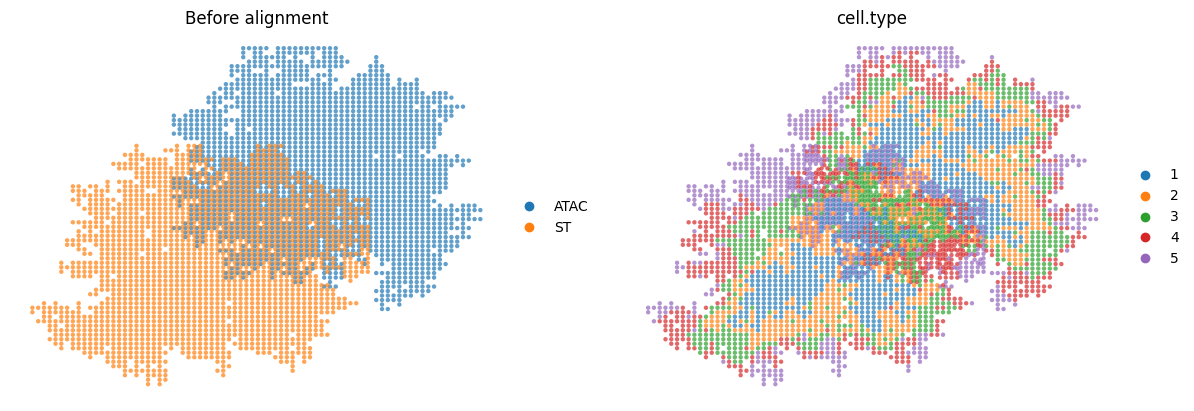

In [25]:
adata=sc.concat([source_adata,target_adata],join='inner')
sc.pl.embedding(adata=adata, basis='spatial',color=['batch','cell.type'],title='Before alignment',size=40,alpha=0.7,frameon=False)

In [26]:
%%time
source = source_adata.obsm['spatial'].astype(np.float32) 
target = target_adata.obsm['spatial'].astype(np.float32)  

aligned_spatial, theta_deg, translation,scale= Rigid_alignment(source, target, epochs=1000, sample_size=10000,enable_scale=False,device=device)
source_adata.obsm['spatial'] = aligned_spatial

Scanning angles to find best starting angle...


Global Align: 100%|███████████████████████████████████| 1000/1000 [00:02<00:00, 463.15it/s, Loss=0.00, Scale=1.000, Rot=-90.00°, Trans=(-20.0, -20.0)]

Peak GPU memory usage: 0.091 GB
Scale factor: 1.000, Rotation angle: -90.00°, Translation (x, y): (-20.00, -20.00)
CPU times: user 2.22 s, sys: 28.9 ms, total: 2.25 s
Wall time: 2.23 s


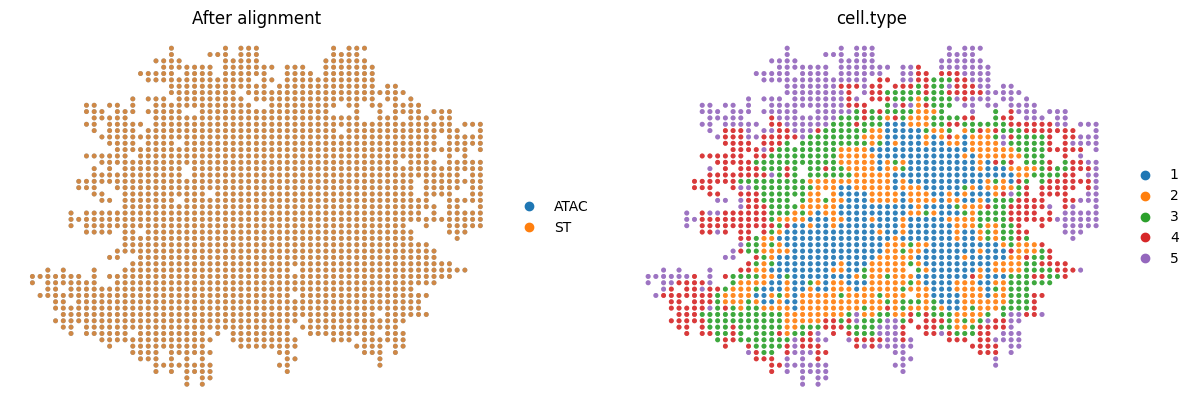

In [27]:
adata=sc.concat([source_adata,target_adata],join='inner')
sc.pl.embedding(adata=adata, basis='spatial',color=['batch','cell.type'],title='After alignment',size=50,alpha=0.7,frameon=False)

In [28]:
CI=evaluation(source_adata.obsm['spatial'],target_adata.obsm['spatial'],source_adata.obs['cell.type'],target_adata.obs['cell.type'])
CI

1.0

Connected sampling (total 50):
   - Correct pairing (Black): 50
   - Incorrect pairing (red): 0


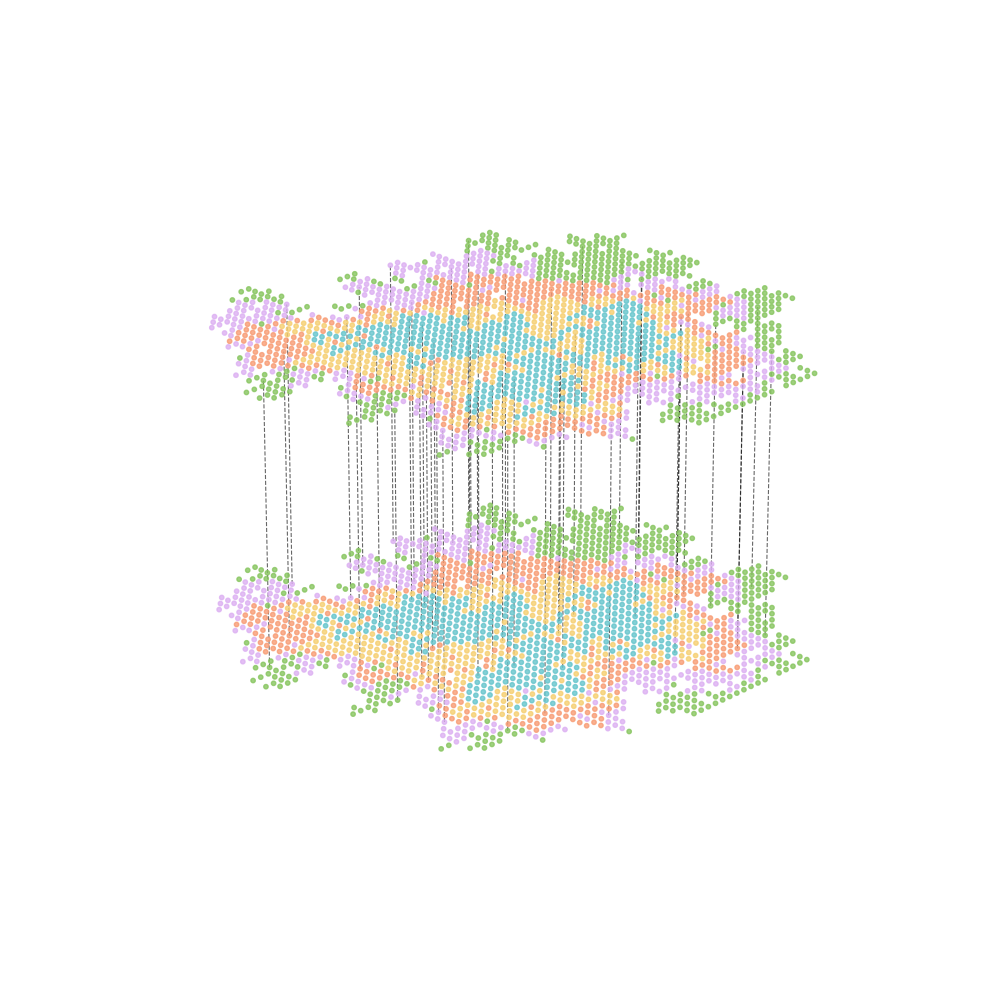

In [29]:
color_dict=create_new_color_dict(adata,cat_key='cell.type')
plot_2d_alignment_to_3d_flow(
    source_adata=source_adata,
    target_adata=target_adata,
    label_key='cell.type',        
    palette=color_dict,        
    n_lines=50,               
    height_scale=0.4,
    alpha_points=0.8,
    size=10,                  
    #save_path='/home/dbj/LPcross/Data/result/simATAC_align/alignment_flow_3d.png'
)

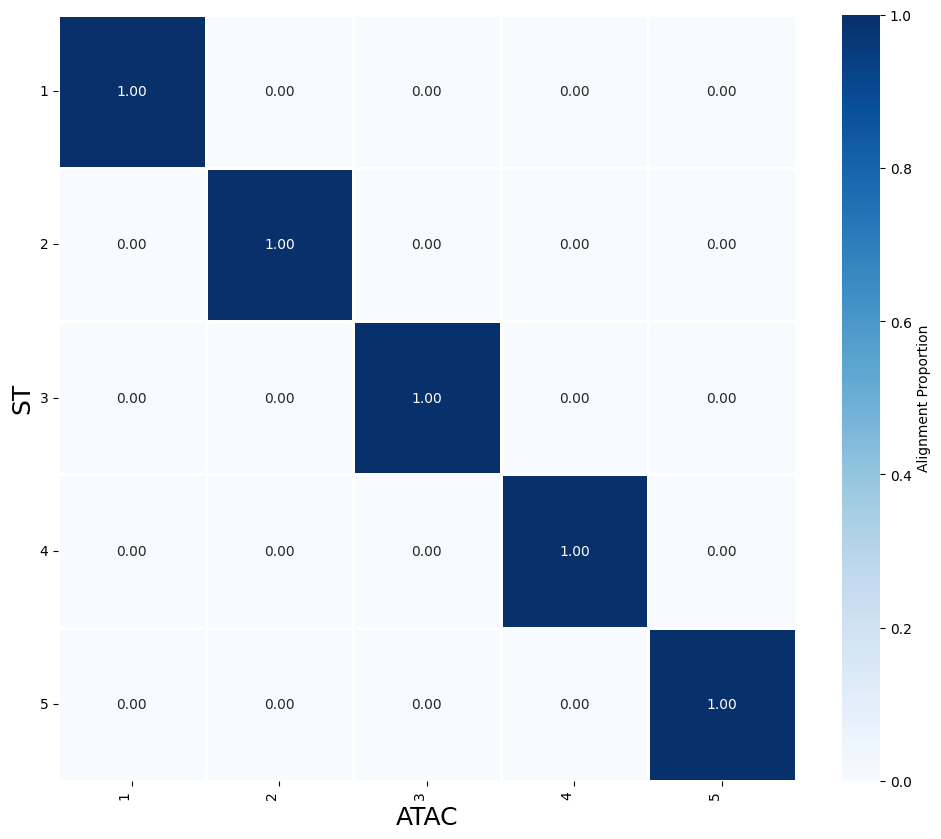

In [30]:
from scipy.spatial import cKDTree
import seaborn as sns
import matplotlib.pyplot as plt
source_label_key = 'cell.type' 
target_label_key = 'cell.type'
source_coords = source_adata.obsm['spatial']  
target_coords = target_adata.obsm['spatial']

tree = cKDTree(target_coords)
distances, indices = tree.query(source_coords, k=1)

source_labels = source_adata.obs[source_label_key].values
matched_target_labels = target_adata.obs[target_label_key].iloc[indices.flatten()].values

df_crosstab = pd.crosstab(
    index=pd.Series(matched_target_labels, name='Target Labels (Y)'),
    columns=pd.Series(source_labels, name='Source Labels (X)'),
    normalize='columns' 
)

plt.figure(figsize=(10, 8.5))
sns.heatmap(df_crosstab, annot=True,cmap='Blues',fmt='.2f',linewidths=1, cbar_kws={'label': 'Alignment Proportion'})
plt.grid(False) 
plt.title('', fontsize=14, pad=15)
plt.xlabel('ATAC', fontsize=18)
plt.ylabel('ST', fontsize=18)
plt.xticks(rotation=90, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## <span style="color:black; font-weight:bold;">Loading enhanced2 data</span>

In [31]:
source_adata=sc.read_h5ad('/home/dbj/LPcross/Data/data/alignment_sim/ATAC_sim/enhanced2/adata_atac_sim4.h5ad')
source_adata.obs['batch']='ATAC'


target_adata=sc.read_h5ad('/home/dbj/LPcross/Data/data/alignment_sim/RNA_sim/enhanced2/adata_rna_trans_sim4.h5ad')
target_adata.obs['batch']='ST'

In [32]:
rotate_and_translate_spatial(source_adata,angle_deg=120,dx=20,dy=20)

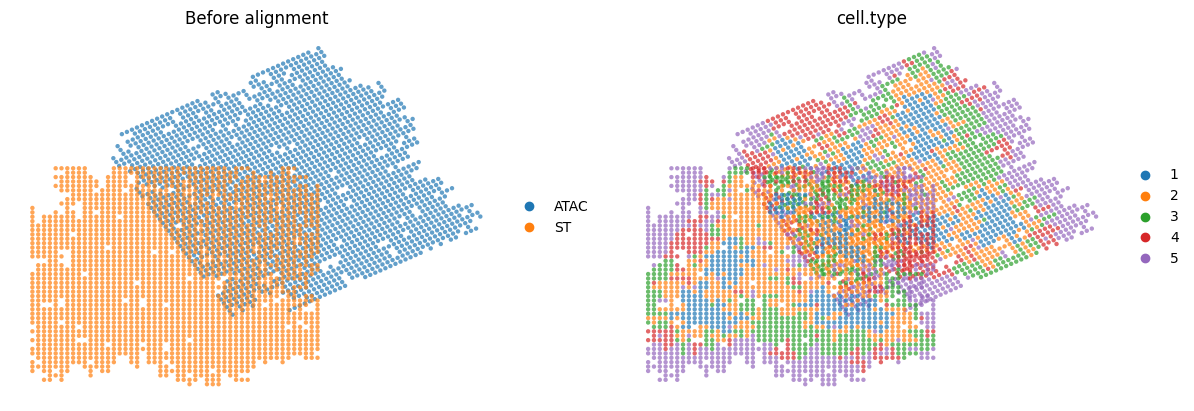

In [33]:
adata=sc.concat([source_adata,target_adata],join='inner')
sc.pl.embedding(adata=adata, basis='spatial',color=['batch','cell.type'],title='Before alignment',size=40,alpha=0.7,frameon=False)

In [34]:
%%time
source = source_adata.obsm['spatial'].astype(np.float32) 
target = target_adata.obsm['spatial'].astype(np.float32)  

aligned_spatial, theta_deg, translation,scale= Rigid_alignment(source, target, epochs=1000, sample_size=10000,enable_scale=False,device=device)
source_adata.obsm['spatial'] = aligned_spatial

Scanning angles to find best starting angle...


Global Align: 100%|██████████████████████████████████| 1000/1000 [00:02<00:00, 481.10it/s, Loss=0.08, Scale=1.000, Rot=-120.00°, Trans=(-20.0, -20.0)]

Peak GPU memory usage: 0.098 GB
Scale factor: 1.000, Rotation angle: -120.00°, Translation (x, y): (-20.07, -20.00)
CPU times: user 2.1 s, sys: 61.7 ms, total: 2.16 s
Wall time: 2.14 s


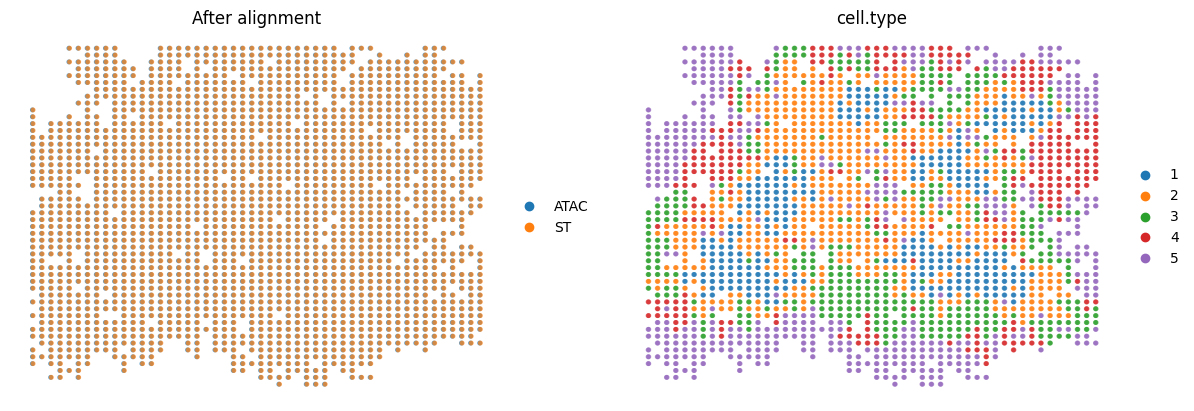

In [35]:
adata=sc.concat([source_adata,target_adata],join='inner')
sc.pl.embedding(adata=adata, basis='spatial',color=['batch','cell.type'],title='After alignment',size=50,alpha=0.7,frameon=False)

In [36]:
CI=evaluation(source_adata.obsm['spatial'],target_adata.obsm['spatial'],source_adata.obs['cell.type'],target_adata.obs['cell.type'])
CI

1.0

Connected sampling (total 50):
   - Correct pairing (Black): 50
   - Incorrect pairing (red): 0


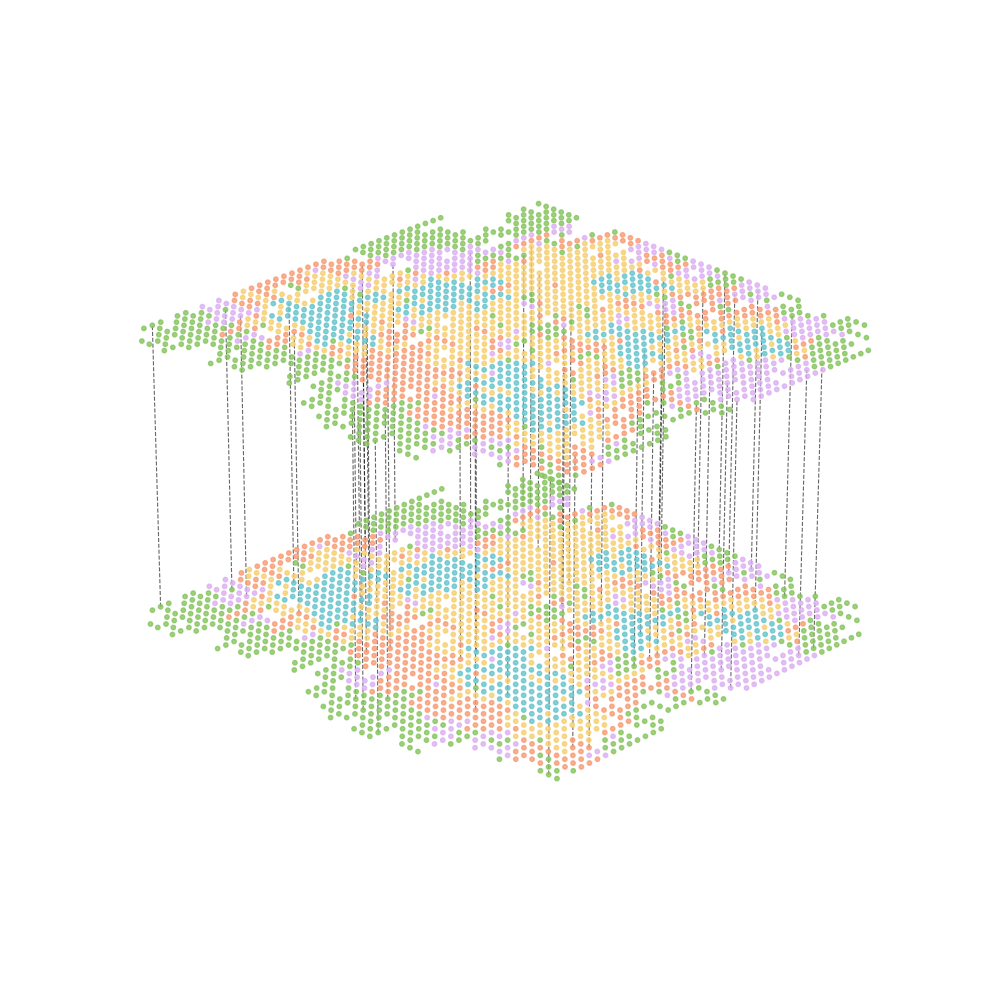

In [37]:
color_dict=create_new_color_dict(adata,cat_key='cell.type')
plot_2d_alignment_to_3d_flow(
    source_adata=source_adata,
    target_adata=target_adata,
    label_key='cell.type',        
    palette=color_dict,        
    n_lines=50,               
    height_scale=0.4,
    alpha_points=0.8,
    size=10,                  
    #save_path='/home/dbj/LPcross/Data/result/simATAC_align/alignment_flow_3d.png'
)

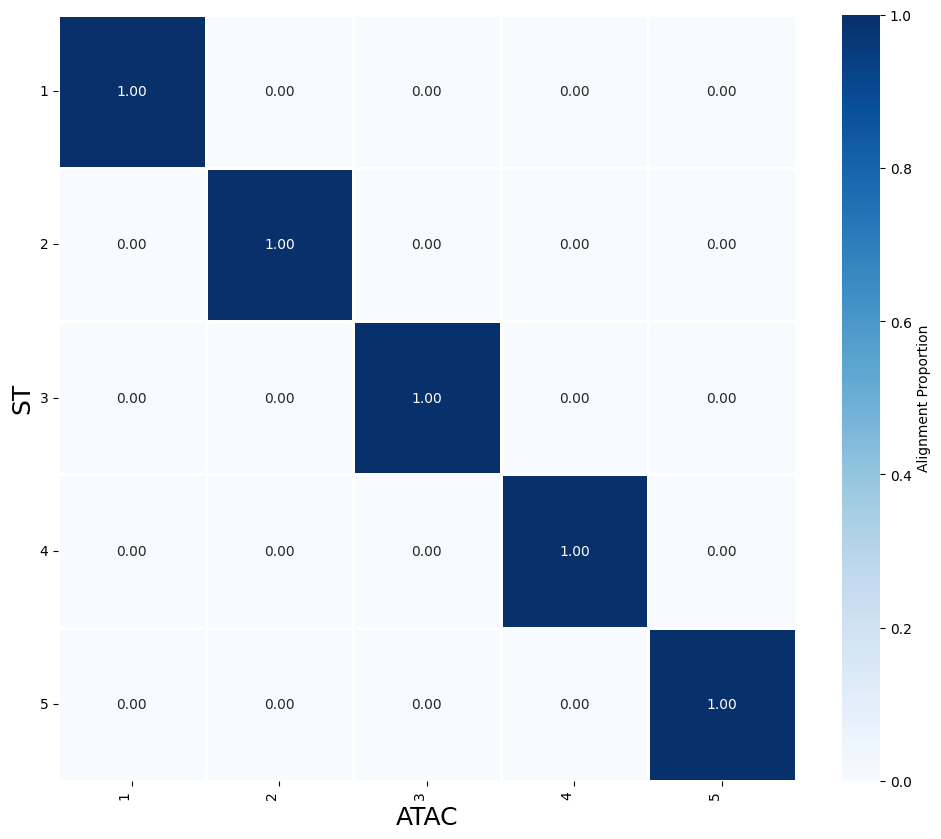

In [38]:
from scipy.spatial import cKDTree
import seaborn as sns
import matplotlib.pyplot as plt
source_label_key = 'cell.type' 
target_label_key = 'cell.type'
source_coords = source_adata.obsm['spatial']  
target_coords = target_adata.obsm['spatial']

tree = cKDTree(target_coords)
distances, indices = tree.query(source_coords, k=1)

source_labels = source_adata.obs[source_label_key].values
matched_target_labels = target_adata.obs[target_label_key].iloc[indices.flatten()].values

df_crosstab = pd.crosstab(
    index=pd.Series(matched_target_labels, name='Target Labels (Y)'),
    columns=pd.Series(source_labels, name='Source Labels (X)'),
    normalize='columns' 
)

plt.figure(figsize=(10, 8.5))
sns.heatmap(df_crosstab, annot=True,cmap='Blues',fmt='.2f',linewidths=1, cbar_kws={'label': 'Alignment Proportion'})
plt.grid(False) 
plt.title('', fontsize=14, pad=15)
plt.xlabel('ATAC', fontsize=18)
plt.ylabel('ST', fontsize=18)
plt.xticks(rotation=90, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()